In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

crop_path = "../data/processed/crop_yield_clean.csv"
soil_path = "../data/processed/state_soil_data_clean.csv"
weather_path = "../data/processed/state_weather_data_clean.csv"

crop = pd.read_csv(crop_path)
soil = pd.read_csv(soil_path)
weather = pd.read_csv(weather_path)

print("Crop shape:", crop.shape)
print("Soil shape:", soil.shape)
print("Weather shape:", weather.shape)
crop.head(), soil.head(), weather.head()

Crop shape: (19689, 9)
Soil shape: (30, 5)
Weather shape: (720, 5)


(           crop  year      season  state     area  production  fertilizer  \
 0      Arecanut  1997  Whole Year  Assam  73814.0       56708  7024878.38   
 1     Arhar/Tur  1997      Kharif  Assam   6637.0        4685   631643.29   
 2   Castor seed  1997      Kharif  Assam    796.0          22    75755.32   
 3       Coconut  1997  Whole Year  Assam  19656.0   126905000  1870661.52   
 4  Cotton(lint)  1997      Kharif  Assam   1739.0         794   165500.63   
 
    pesticide        yield  
 0   22882.34     0.796087  
 1    2057.47     0.710435  
 2     246.76     0.238333  
 3    6093.36  5238.051739  
 4     539.09     0.420909  ,
                state   N   P   K   pH
 0     Andhra Pradesh  78  45  22  6.8
 1  Arunachal Pradesh  55  15  35  5.5
 2              Assam  60  18  38  5.8
 3              Bihar  85  30  25  7.2
 4       Chhattisgarh  70  35  20  6.5,
             state  year  avg_temp_c  total_rainfall_mm  avg_humidity_percent
 0  Andhra Pradesh  1997       28.21      

In [ ]:
# Load and inspect NDVI data (will be merged later)
ndvi_path = "../data/raw/india_state_ndvi_2000_2020.csv"
ndvi = pd.read_csv(ndvi_path)

print("NDVI raw shape:", ndvi.shape)
ndvi.head()

In [ ]:
# NDVI basic cleaning and anomaly checks
ndvi["state"] = ndvi["state"].astype(str).str.strip()
ndvi["year"] = pd.to_numeric(ndvi["year"], errors="coerce").astype("Int64")
ndvi["mean_ndvi"] = pd.to_numeric(ndvi["mean_ndvi"], errors="coerce")

print("NDVI info:")
print(ndvi.info())
print("\nNDVI missing values per column:")
print(ndvi.isna().sum())

print("\nNDVI value range (mean_ndvi):")
print(ndvi["mean_ndvi"].describe())

# Check for obvious anomalies: values outside [0, 1]
ndvi_outside_01 = ndvi[(ndvi["mean_ndvi"] < 0) | (ndvi["mean_ndvi"] > 1)]
print("\nNDVI values outside [0, 1]:", len(ndvi_outside_01))

# Check state name alignment with crop/weather
crop_states = set(crop["state"].unique())
ndvi_states = set(ndvi["state"].unique())
print("\nStates in NDVI but not in crop data:")
print(sorted(ndvi_states - crop_states))
print("\nStates in crop data but not in NDVI:")
print(sorted(crop_states - ndvi_states))

In [ ]:
# Simple normalization of known state name differences
state_renames = {
    "Orissa": "Odisha",
}
ndvi["state"] = ndvi["state"].replace(state_renames)

# Re-check alignment after renaming
ndvi_states = set(ndvi["state"].unique())
print("\nAfter renaming, states in NDVI but not in crop data:")
print(sorted(ndvi_states - crop_states))
print("States in crop data but not in NDVI:")
print(sorted(crop_states - ndvi_states))

In [9]:
# Standardize join keys
for df in (crop, soil, weather):
    df["state"] = df["state"].astype(str).str.strip()

crop["year"] = pd.to_numeric(crop["year"], errors="coerce").astype("Int64")
weather["year"] = pd.to_numeric(weather["year"], errors="coerce").astype("Int64")

print("Unique states in crop not in soil:")
print(sorted(set(crop["state"]) - set(soil["state"])))
print("Unique states in crop not in weather:")
print(sorted(set(crop["state"]) - set(weather["state"])))

Unique states in crop not in soil:
[]
Unique states in crop not in weather:
[]


In [10]:
# Merge crop with soil (state-level static features)
crop_soil = crop.merge(soil, on="state", how="left", suffixes=("", "_soil"))
print("After soil merge:", crop_soil.shape)
crop_soil.head()

After soil merge: (19689, 13)


,crop,year,season,state,area,production,fertilizer,pesticide,yield,N,P,K,pH
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087,60,18,38,5.8
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435,60,18,38,5.8
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333,60,18,38,5.8
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739,60,18,38,5.8
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909,60,18,38,5.8


In [ ]:
# Merge NDVI (state-year) for years where NDVI is available (2000–2020)
ndvi_year_min, ndvi_year_max = int(ndvi["year"].min()), int(ndvi["year"].max())
print("NDVI year range:", ndvi_year_min, "to", ndvi_year_max)

# Restrict crop_soil_weather to years within NDVI coverage when merging
mask_ndvi_year = (crop_soil_weather["year"] >= ndvi_year_min) & (crop_soil_weather["year"] <= ndvi_year_max)
csw_ndvi_window = crop_soil_weather.loc[mask_ndvi_year].copy()

print("Rows in crop_soil_weather overall:", len(crop_soil_weather))
print("Rows in NDVI year window:", len(csw_ndvi_window))

csw_ndvi = csw_ndvi_window.merge(
    ndvi[["state", "year", "mean_ndvi"]],
    on=["state", "year"],
    how="left",
)
print("After NDVI merge:", csw_ndvi.shape)

# Check for missing NDVI after merge (should correspond to states/years without NDVI coverage)
missing_ndvi = csw_ndvi["mean_ndvi"].isna().sum()
print("Missing NDVI values after merge:", missing_ndvi)

print("\nNDVI stats in merged dataset:")
print(csw_ndvi["mean_ndvi"].describe())

In [ ]:
# Save ML-ready dataset with NDVI
import os
os.makedirs("../data/processed", exist_ok=True)

features_path_ndvi = "../data/processed/crop_yield_ml_features_with_ndvi.csv"
csw_ndvi.to_csv(features_path_ndvi, index=False)
print("Saved merged ML feature dataset with NDVI to", features_path_ndvi)

In [11]:
# Merge in weather (state-year-level features)
crop_soil_weather = crop_soil.merge(
    weather,
    on=["state", "year"],
    how="left",
    suffixes=("", "_weather"),
)
print("After weather merge:", crop_soil_weather.shape)
crop_soil_weather.head()

After weather merge: (19689, 16)


,crop,year,season,state,area,production,fertilizer,pesticide,yield,N,P,K,pH,avg_temp_c,total_rainfall_mm,avg_humidity_percent
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087,60,18,38,5.8,22.41,1468.92,70.71
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435,60,18,38,5.8,22.41,1468.92,70.71
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333,60,18,38,5.8,22.41,1468.92,70.71
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739,60,18,38,5.8,22.41,1468.92,70.71
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909,60,18,38,5.8,22.41,1468.92,70.71


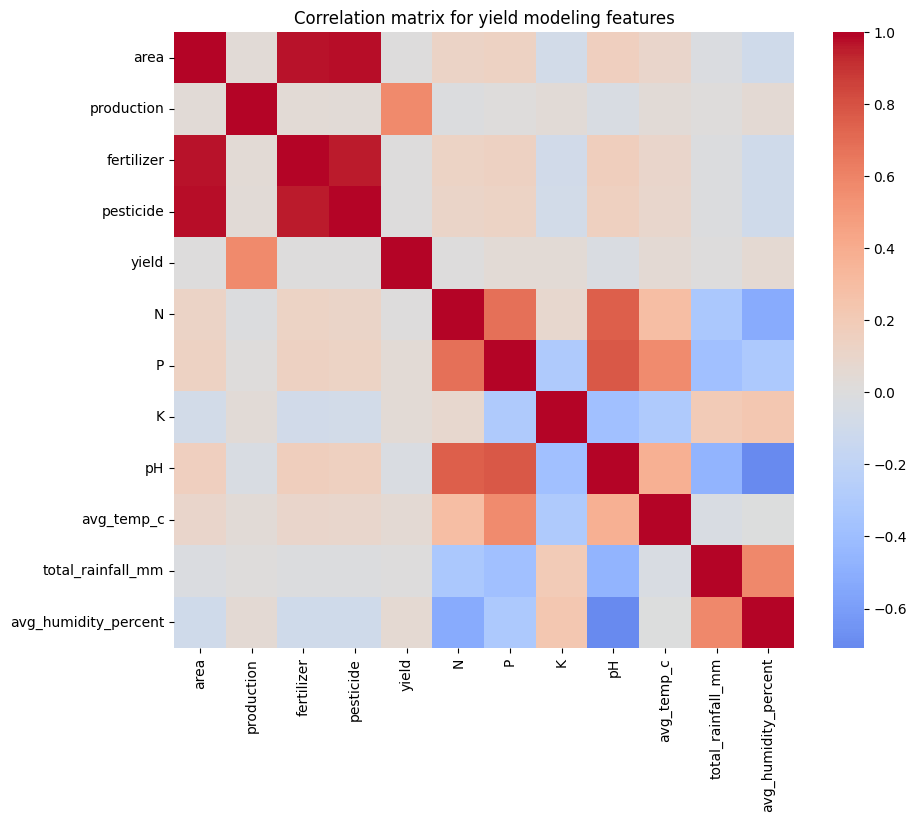

Features most correlated with yield:


yield                   1.000000
production              0.570809
avg_humidity_percent    0.063663
avg_temp_c              0.048464
K                       0.043650
P                       0.040731
total_rainfall_mm       0.005191
fertilizer              0.002862
area                    0.001858
pesticide               0.001782
N                       0.000567
pH                     -0.021938
Name: yield, dtype: float64

In [12]:
# Basic correlation analysis for yield vs. inputs and climate
feature_cols = [
    "area", "production", "fertilizer", "pesticide", "yield",
    "N", "P", "K", "pH",
    "avg_temp_c", "total_rainfall_mm", "avg_humidity_percent",
]

corr = crop_soil_weather[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation matrix for yield modeling features")
plt.show()

print("Features most correlated with yield:")
display(corr["yield"].sort_values(ascending=False))

In [13]:
# Example: per-crop feature summary for modeling
per_crop_summary = (
    crop_soil_weather
    .groupby(["crop", "state"], as_index=False)[
        ["year", "yield", "N", "P", "K", "pH", "avg_temp_c", "total_rainfall_mm", "avg_humidity_percent"]
    ]
    .agg({
        "year": ["min", "max", "nunique"],
        "yield": ["mean", "max"],
        "avg_temp_c": "mean",
        "total_rainfall_mm": "mean",
        "avg_humidity_percent": "mean",
        "N": "mean",
        "P": "mean",
        "K": "mean",
        "pH": "mean",
    })
)
per_crop_summary.head()

crop           state  year                   yield             \
                              min   max nunique      mean        max   
0  Arecanut  Andhra Pradesh  2000  2019      18  2.211056   7.253333   
1  Arecanut           Assam  1997  2019      22  0.898712   1.557037   
2  Arecanut             Goa  1998  2019      13  1.631923   1.965000   
3  Arecanut       Karnataka  1997  2019      21  6.558030  10.948182   
4  Arecanut          Kerala  1997  2019      23  0.888012   1.147857   

  avg_temp_c total_rainfall_mm avg_humidity_percent     N     P     K   pH  
        mean              mean                 mean  mean  mean  mean mean  
0  28.030000       1018.535000            69.604444  78.0  45.0  22.0  6.8  
1  22.942273       1912.478182            76.250455  60.0  18.0  38.0  5.8  
2  27.434615       2059.407692            73.330769  65.0  25.0  45.0  6.2  
3  23.683810        866.529048            68.212381  72.0  42.0  25.0  6.9  
4  26.894348       1797.989130            80.164348  65.0  28.0  50.0  5.7

In [14]:
# Save ML-ready row-level dataset
import os
os.makedirs("../data/processed", exist_ok=True)

features_path = "../data/processed/crop_yield_ml_features.csv"
crop_soil_weather.to_csv(features_path, index=False)
print("Saved merged ML feature dataset to", features_path)

Saved merged ML feature dataset to ../data/processed/crop_yield_ml_features.csv
